# Appendix D: Joint Optimization and Fresh Sionna RT Experiments

This notebook runs two explicitly labeled experiment tracks:

- **E4–E8 finite-model validation:** uncertainty sets, robust SOCP beams, full-history LP policies, and causal stress diagnostics.
- **Fresh Sionna RT spatial validation:** independently drop new UEs in each macro, ray trace DL and UL channels, estimate directions from finite UL samples, then calibrate and evaluate on disjoint whole drops.

**The main dynamic Γ sweep keeps TN demands, deadlines, and failure budgets fixed.** Fresh spatial RT uses a separate fixed TN SNR feasibility diagnostic; it does not claim to validate dynamic E7/E8 in a physical scene.

The default `SPATIAL_SOURCE = 'fresh_rt'` recomputes channels on every run. Set it to `'cache'` to reuse a recorded run, or `'none'` for finite-model experiments only. Reusing the same seed reproduces the same random draws; change `SEED` for a new Monte Carlo realization.

Read [APPENDIX_D_EXPERIMENTS.md](APPENDIX_D_EXPERIMENTS.md) for assumptions and output definitions. `QUICK = False` increases sample counts without changing `E4_ALPHA`. The original SectorDrop notebook and earlier result directories are preserved.


In [1]:
from pathlib import Path
import importlib.util, sys
ROOT = Path.cwd()
if not (ROOT / 'run_appendix_d.py').is_file():
    raise RuntimeError('Set the notebook working directory to the project root.')
missing = [p for p in ('numpy','scipy','matplotlib','cvxpy','clarabel')
           if importlib.util.find_spec(p) is None]
if missing:
    raise ImportError(f'The current kernel is missing {missing}. Create a separate environment as described in APPENDIX_D_EXPERIMENTS.md, '
                      'or run %pip install -r requirements-appendix-d.txt in the current kernel. '
                      'A separate environment is recommended to avoid affecting Sionna.')
from run_appendix_d import run_suite
from IPython.display import display, Markdown, Image, FileLinks
from datetime import datetime


## Experiment Configuration

- A smaller Γ imposes a stricter NTN interference limit.
- THETA_DL/UL × fixed no-gap reference service defines the deadline demand; the reference does not change with Γ.
- DELTA_TN is the allowed failure probability per direction/window; DELTA_NTN is the allowed fraction of active time above the INR threshold.
- E4_ALPHA is the separate scene miscoverage target for E4, fixed across quick/full profiles.
- Fresh RT requires the existing Sionna environment and scene assets. It never silently falls back to synthetic channels or an old cache.
- Quick fresh RT uses six independent macro drops (two each for training/calibration/test); this is a pipeline check, not tail-risk certification.
- The static −6 dB TN SNR feasibility diagnostic differs from dynamic deadline-window QoS.


In [2]:
EXPERIMENTS = ['E4', 'E5', 'E6', 'E7', 'E8']  # Use [] for spatial RT only.
QUICK = True
SEED = 20260921
GAMMA_DB = [-15, -10, -5, 0]
THETA_DL, THETA_UL = 0.40, 0.50
DELTA_TN, DELTA_NTN = 0.10, 0.08
E4_ALPHA = 0.10
SPATIAL_SOURCE = 'fresh_rt'  # 'fresh_rt', 'cache', or 'none'
CACHE_DIR = ROOT / 'result/20260916_080614_095092'
RT_NUM_MACROS = 6 if QUICK else 20
RT_MAX_DEPTH = None  # Use the declared RT profile default; set an integer to override.
CACHE_MAX_SECTORS = None  # Evaluate every held-out sector, including every test macro.
if SPATIAL_SOURCE not in {'fresh_rt', 'cache', 'none'}:
    raise ValueError("SPATIAL_SOURCE must be 'fresh_rt', 'cache', or 'none'.")
OUT = ROOT / 'result' / ('appendix_d_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
print('Output directory:', OUT)
print('Spatial source:', SPATIAL_SOURCE)


Output directory: /home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259
Spatial source: fresh_rt


In [3]:
run_suite(OUT, experiments=EXPERIMENTS, quick=QUICK, seed=SEED,
          gamma_db=GAMMA_DB, theta_dl=THETA_DL, theta_ul=THETA_UL,
          delta_tn=DELTA_TN, delta_ntn=DELTA_NTN, e4_alpha=E4_ALPHA,
          cache_dir=CACHE_DIR if SPATIAL_SOURCE == 'cache' else None,
          cache_max_sectors=CACHE_MAX_SECTORS,
          fresh_rt=SPATIAL_SOURCE == 'fresh_rt',
          rt_num_macros=RT_NUM_MACROS if SPATIAL_SOURCE == 'fresh_rt' else None,
          rt_max_depth=RT_MAX_DEPTH if SPATIAL_SOURCE == 'fresh_rt' else None)


Running E4 -> /home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E4


Running E5 -> /home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E5


Running E6 -> /home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E6


Running E7 -> /home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E7


E7: complete-history Gamma=-15 dB


...

[Sector TN drop] accepted=9/12 candidates=172 outdoor=4/12 margin_required=3 dB


[Sector TN drop] accepted=11/12 candidates=220 outdoor=4/12 margin_required=3 dB


[Sector TN drop] accepted=12/12 candidates=236 outdoor=4/12 margin_required=3 dB


Completed. Figures/tables/raw data: /home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259


PosixPath('/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259')

In [4]:
def show_results(name):
    folder = OUT / name
    if not folder.exists():
        display(Markdown(f'{name} was not selected for this run.'))
        return
    for figure in sorted(folder.rglob('*.png')):
        display(Markdown(f'**{figure.relative_to(folder)}**'))
        display(Image(filename=str(figure), width=900))
    display(Markdown(f'**All PDF / CSV / LaTeX / JSON files:** `{folder}`'))
    for directory in [folder] + sorted(p for p in folder.rglob('*') if p.is_dir()):
        if any(p.suffix in {'.pdf', '.csv', '.tex', '.json'} for p in directory.iterdir() if p.is_file()):
            display(FileLinks(str(directory), included_suffixes=['.pdf', '.csv', '.tex', '.json'], recursive=False))


## E4

Calibration and coverage of uncertainty sets for complete coherent channels. Split data by independent complete scenes; distinguish known finite bounds from empirical marginal coverage, and retain missed detections and the UL-silent background.

**e4_calibration.png**

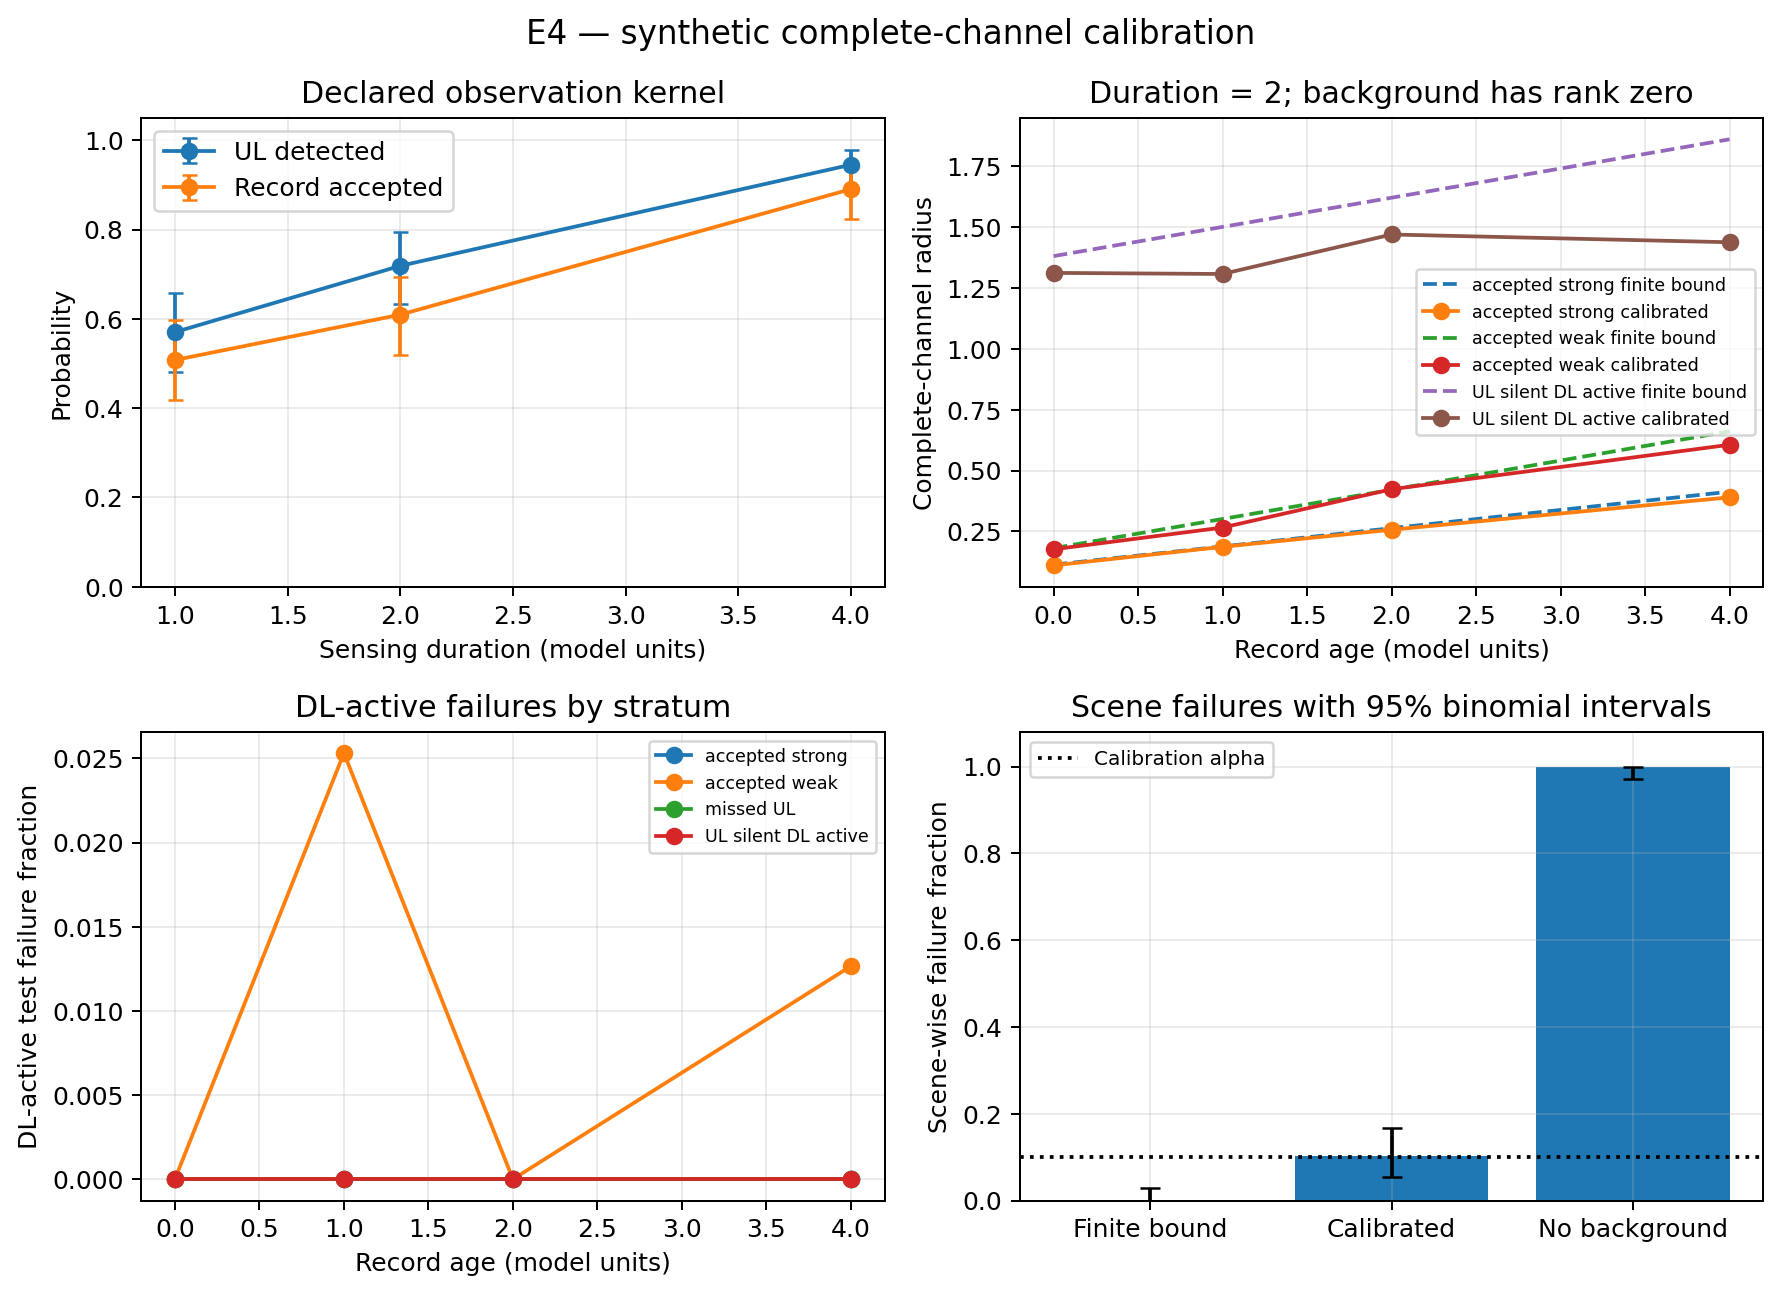

**All PDF / CSV / LaTeX / JSON files:** `/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E4`

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E4/
  coverage_by_state.csv
  calibration_bounds.csv
  scene_coverage.tex
  scene_coverage.csv
  capture_acceptance.csv
  manifest.json
  e4_calibration.pdf
  test_coverage_samples.csv

In [5]:
show_results('E4')

## E5

Exact worst-case leakage, SOCP, the null space at zero interference budget, power backoff, and sweeps over ρ, Γ, set rank, and angular separation, with comparisons against legacy methods and an oracle.

**e5_gamma_rho_sweep.png**

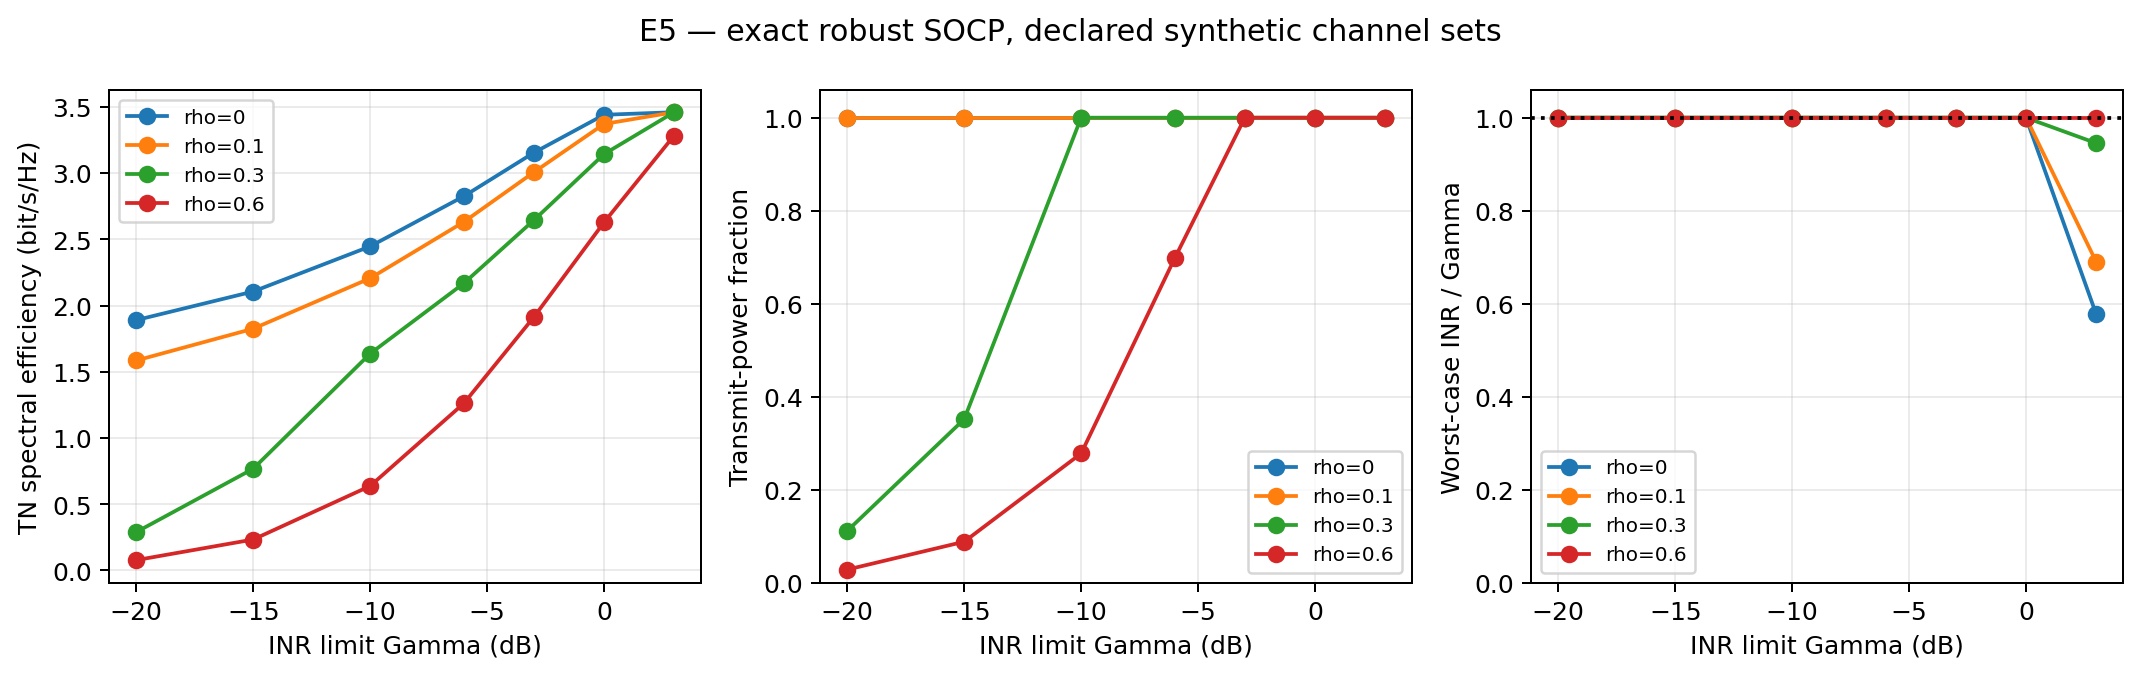

**e5_geometry_sensitivity.png**

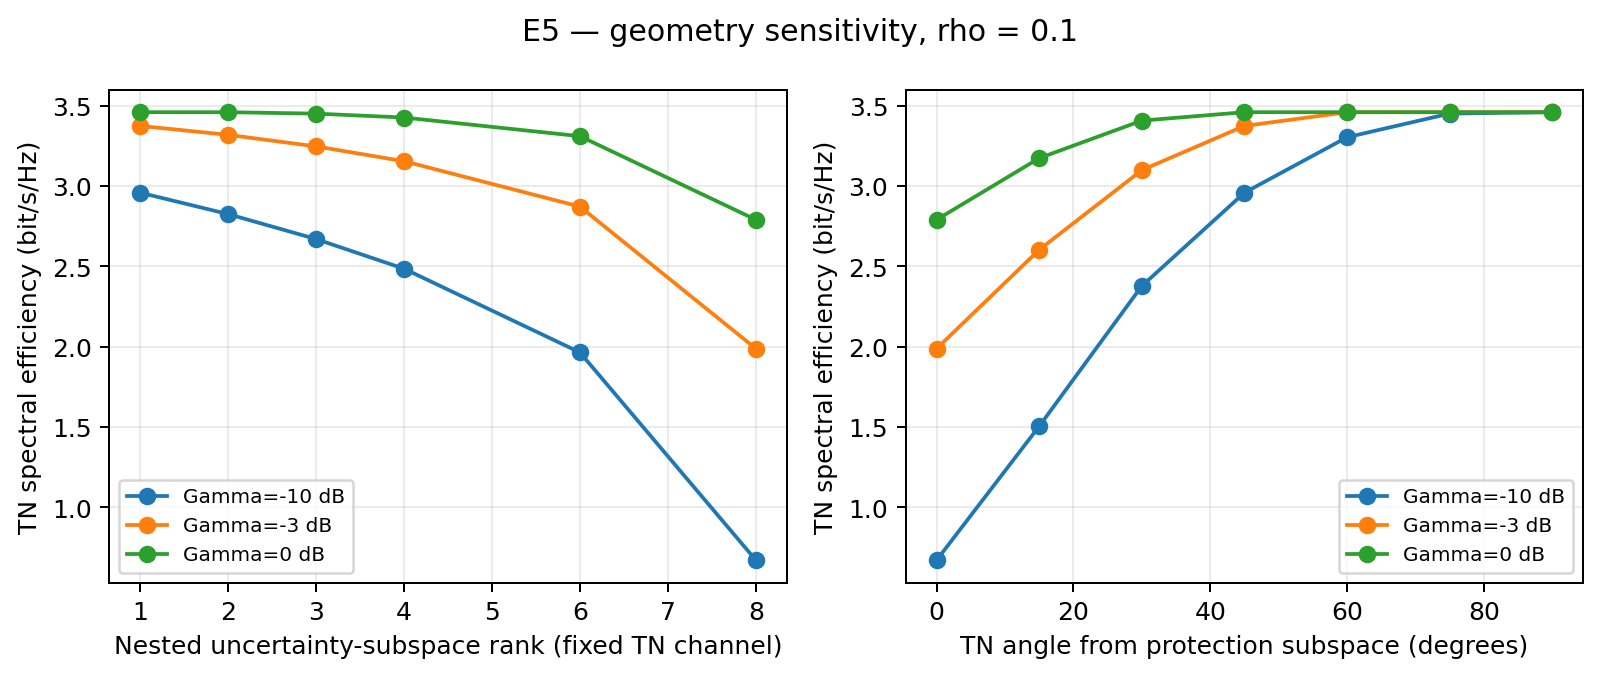

**e5_method_comparison.png**

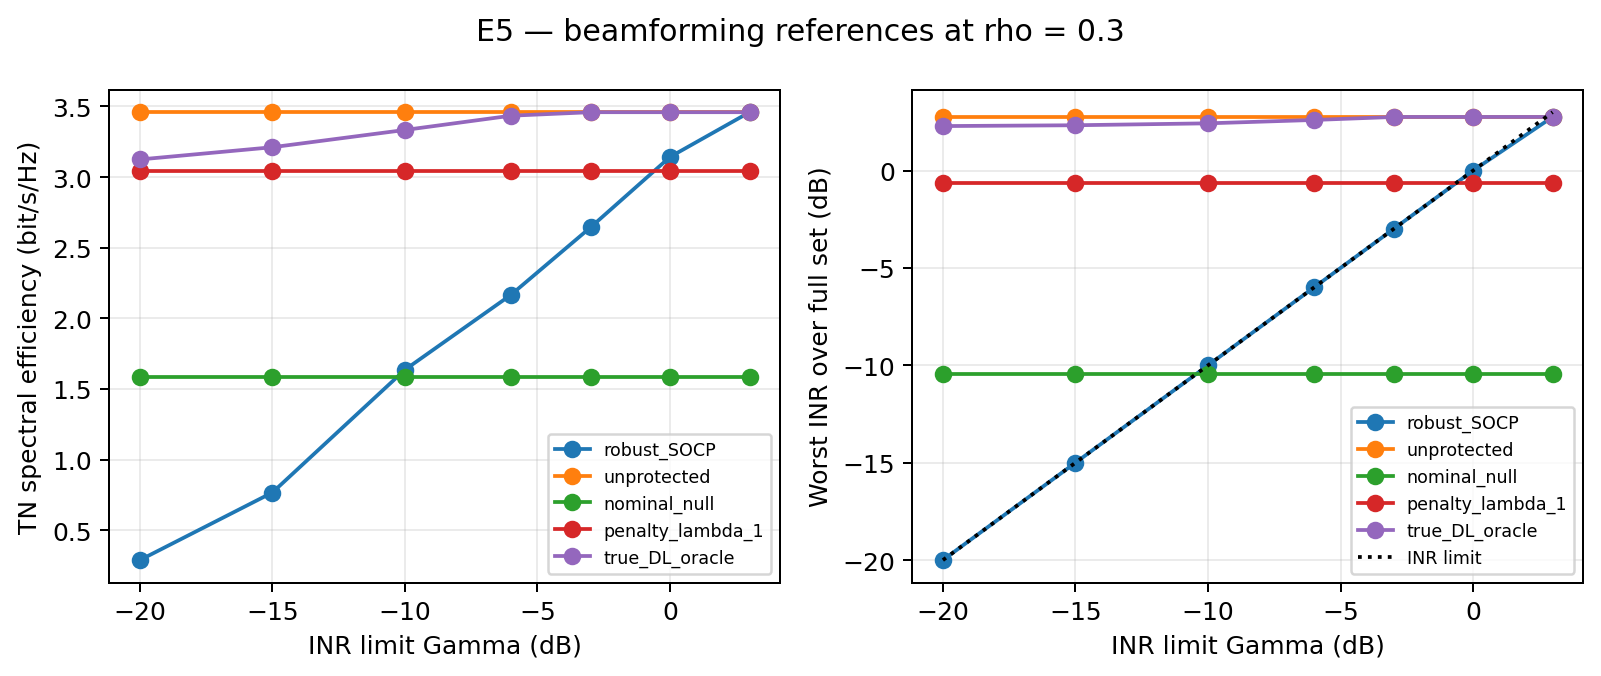

**All PDF / CSV / LaTeX / JSON files:** `/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E5`

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E5/
  phase_invariance.csv
  support_identity.csv
  geometry_sweeps.csv
  identity_summary.csv
  identity_summary.tex
  beam_sweeps.csv
  e5_method_comparison.pdf
  physical_channel_scaling.csv
  e5_gamma_rho_sweep.pdf
  manifest.json
  zero_budget_checks.csv
  beam_comparison.tex
  e5_geometry_sensitivity.pdf

In [6]:
show_results('E5')

## E6

Conditions for beam elimination; enumeration of randomized mixtures of complete deterministic policies versus the occupancy-measure LP; cases requiring randomization and infeasible instances.

**E6_lp_vs_exhaustive.png**

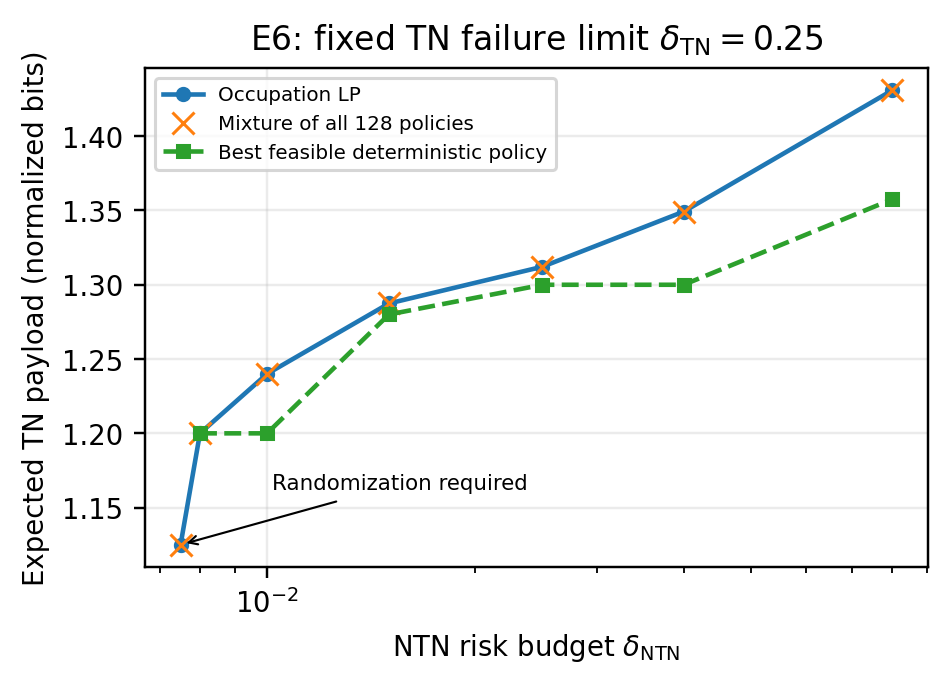

**E6_policy_feasible_region.png**

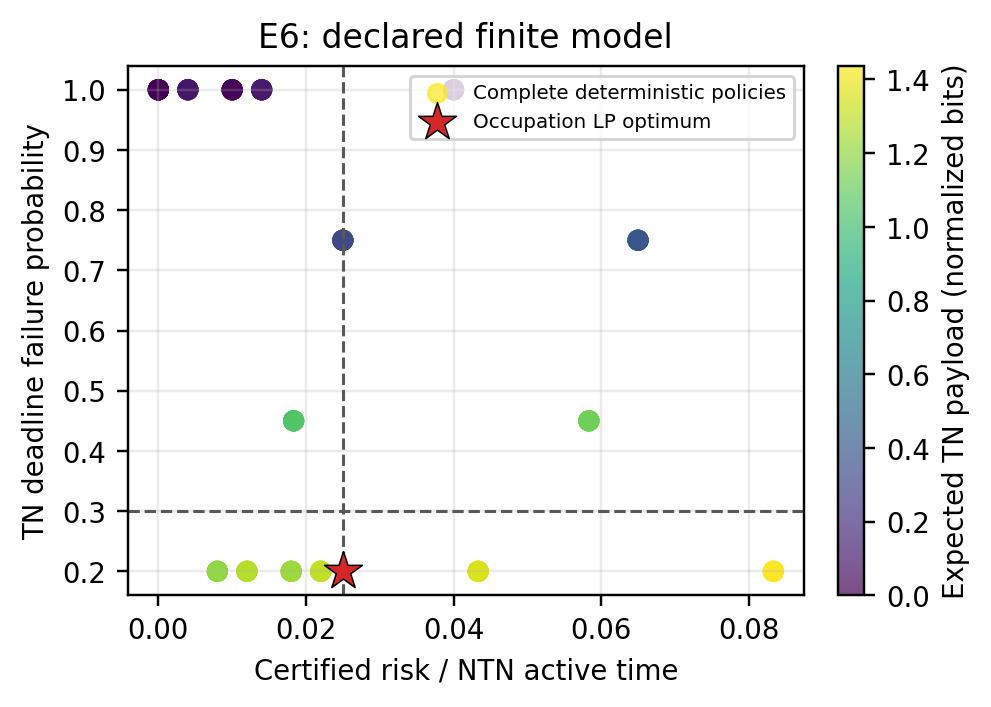

**All PDF / CSV / LaTeX / JSON files:** `/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E6`

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E6/
  E6_all_deterministic_policies.csv
  E6_summary.json
  E6_policy_feasible_region.pdf
  E6_lp_vs_exhaustive.pdf
  E6_randomization_sweep.csv
  E6_validation.csv
  E6_validation_table.tex
  E6_optimal_policy.csv
  E6_beam_elimination.csv

In [7]:
show_results('E6')

## E7

Compare F/T/L/J under the same model: Γ-swept CDFs at fixed TN requirements, TN SNR, net service, timelines, and a separate θ × Γ feasibility map.

**gamma_inr_cdf.png**

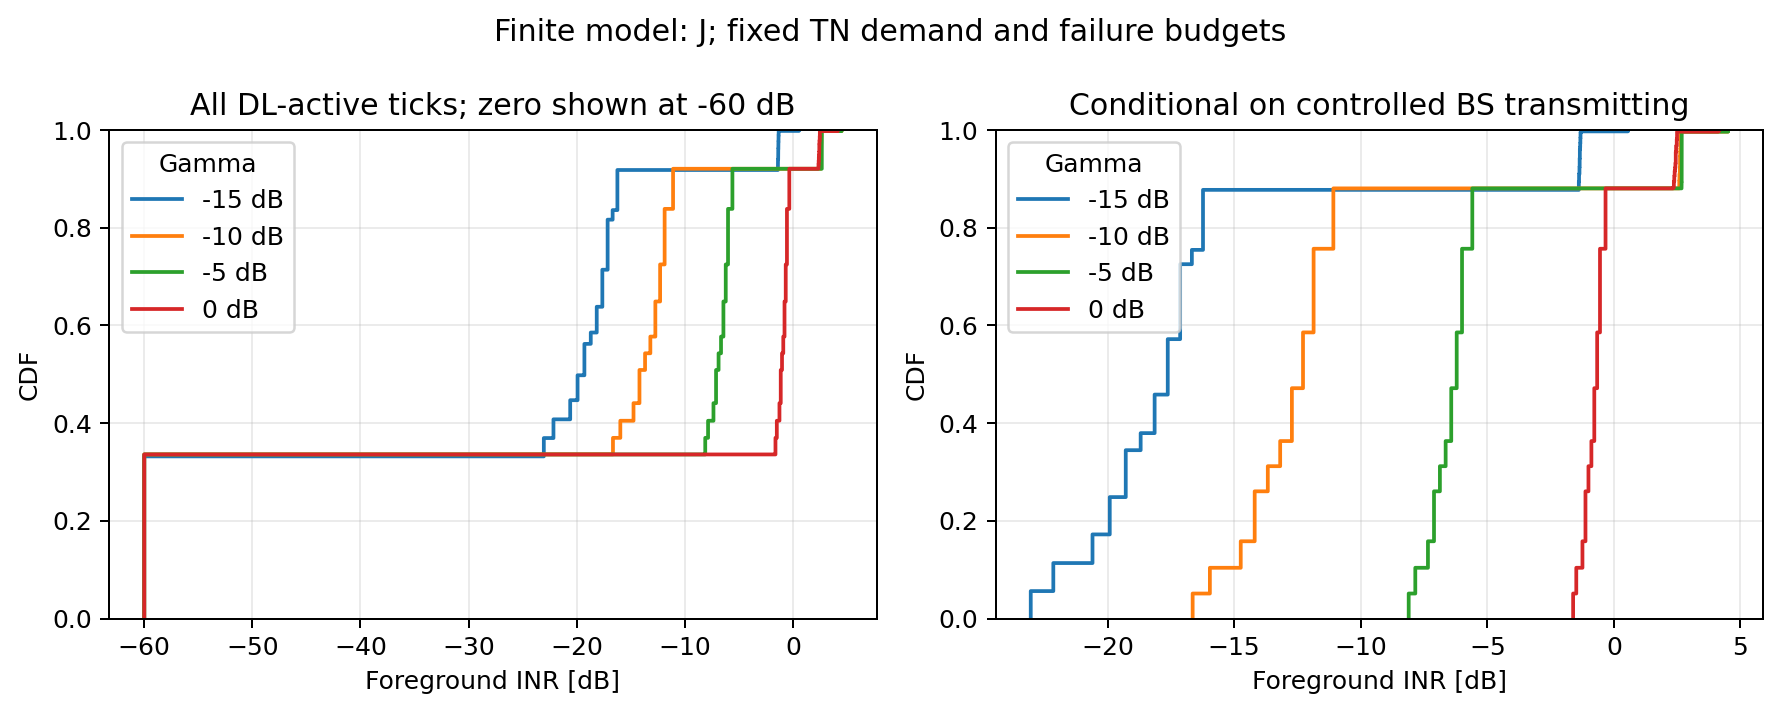

**service_protection_tradeoff.png**

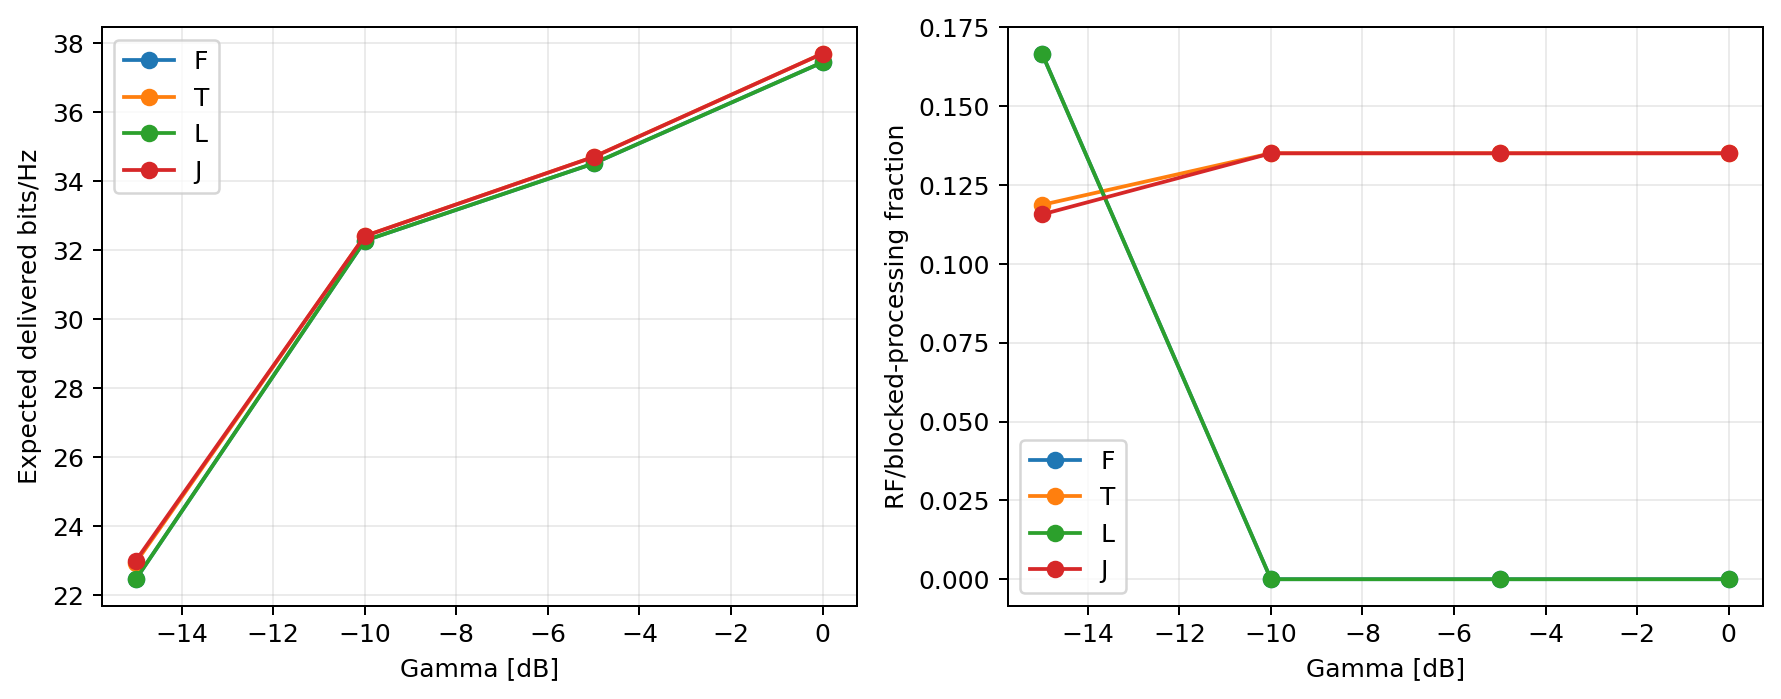

**silent_ntn_and_tn_cdf.png**

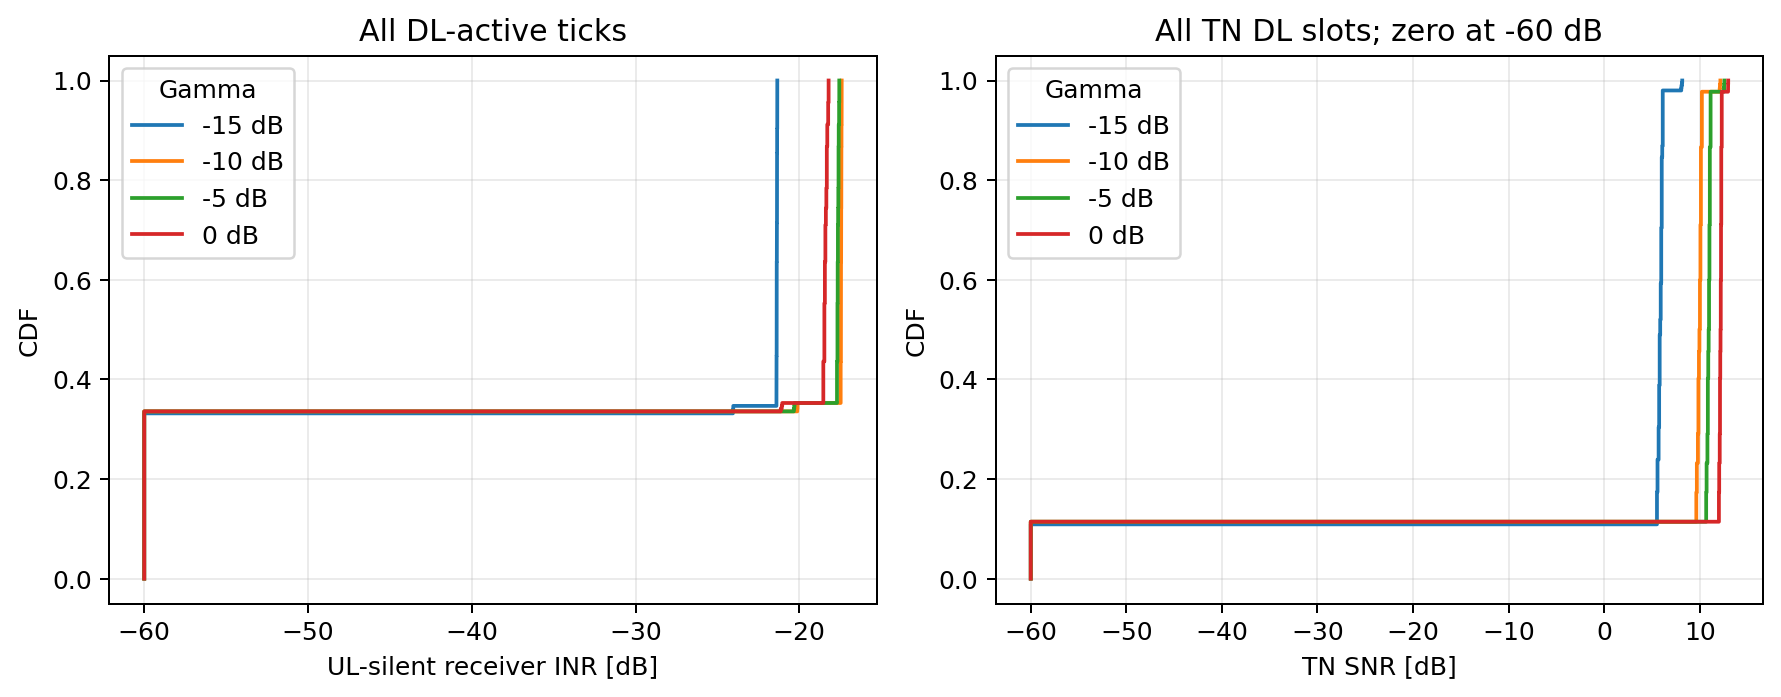

**timeline.png**

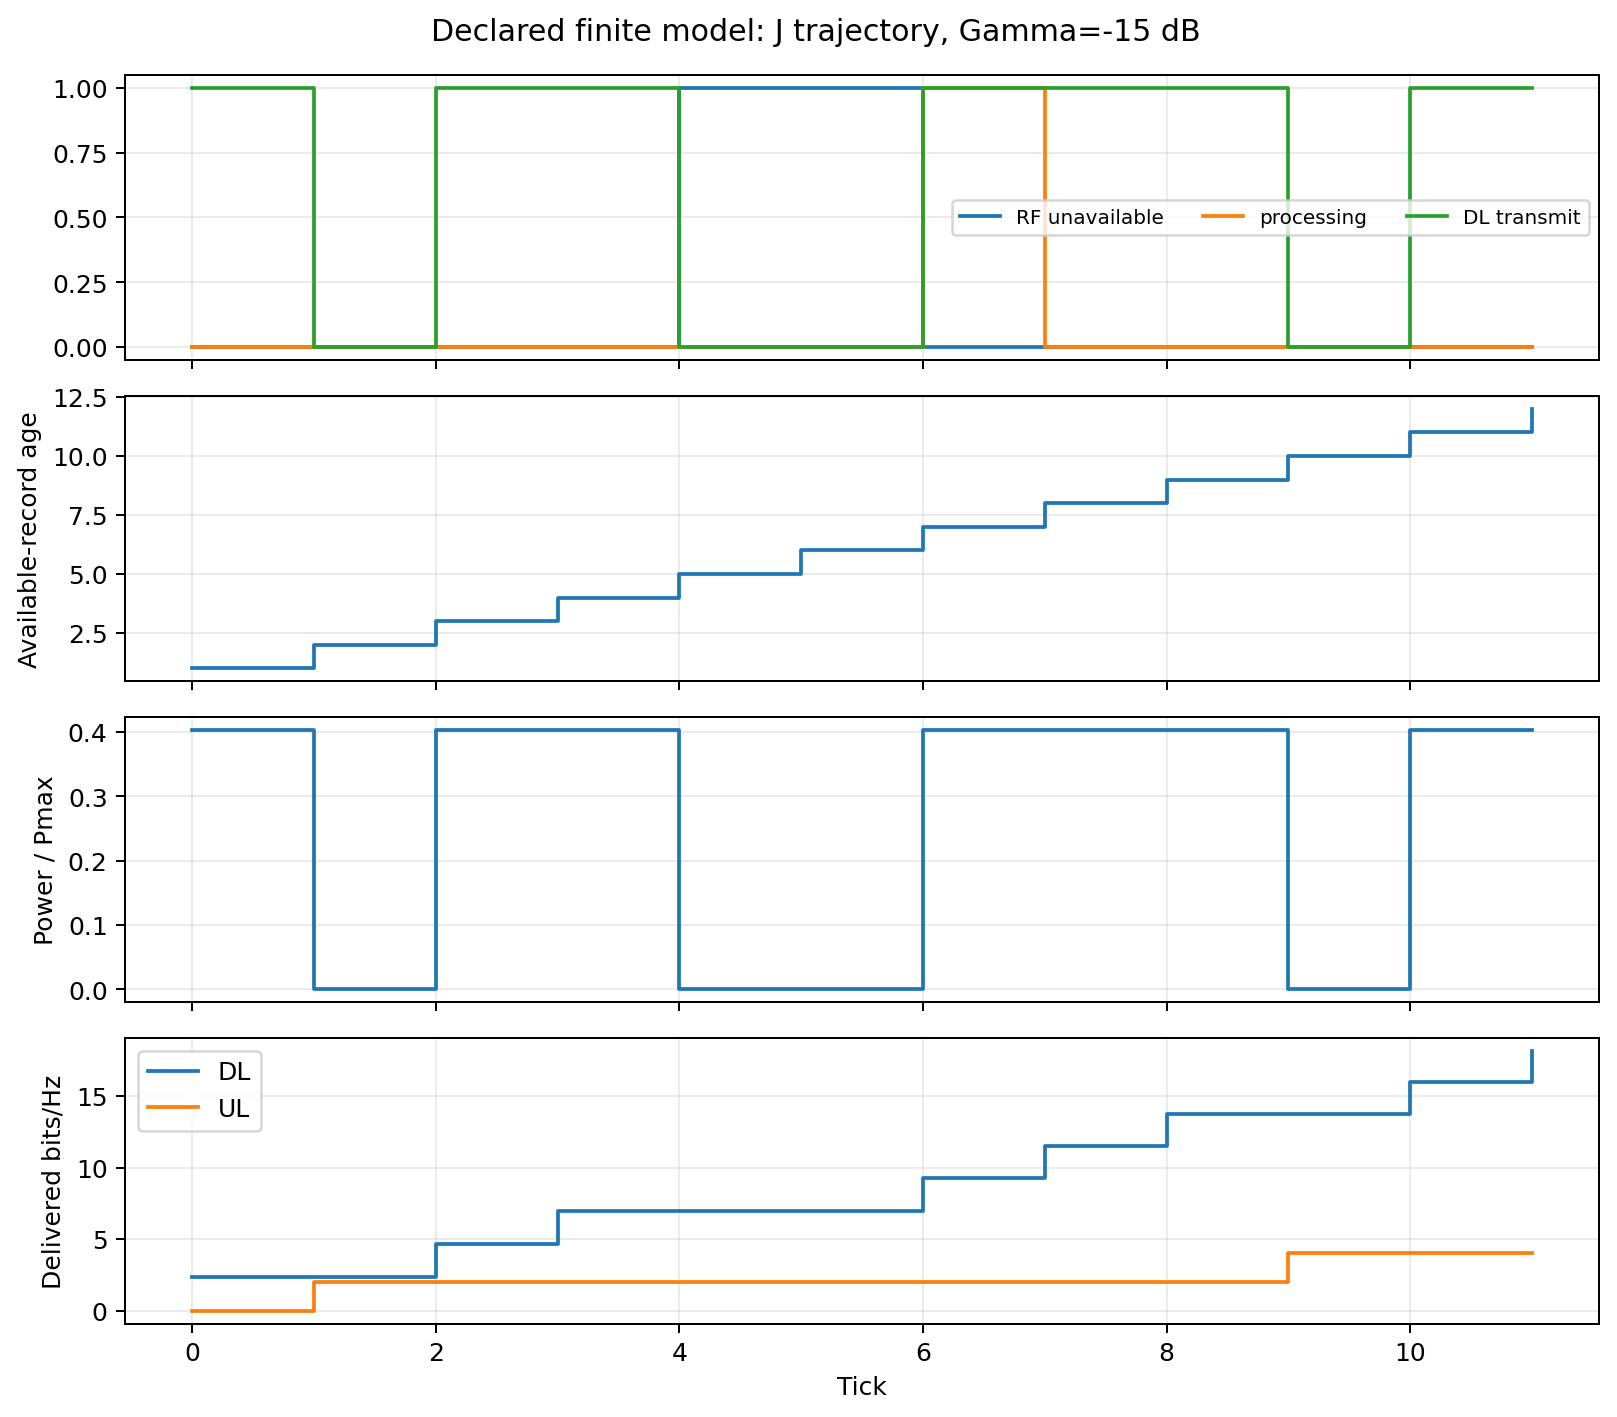

**tn_demand_feasibility.png**

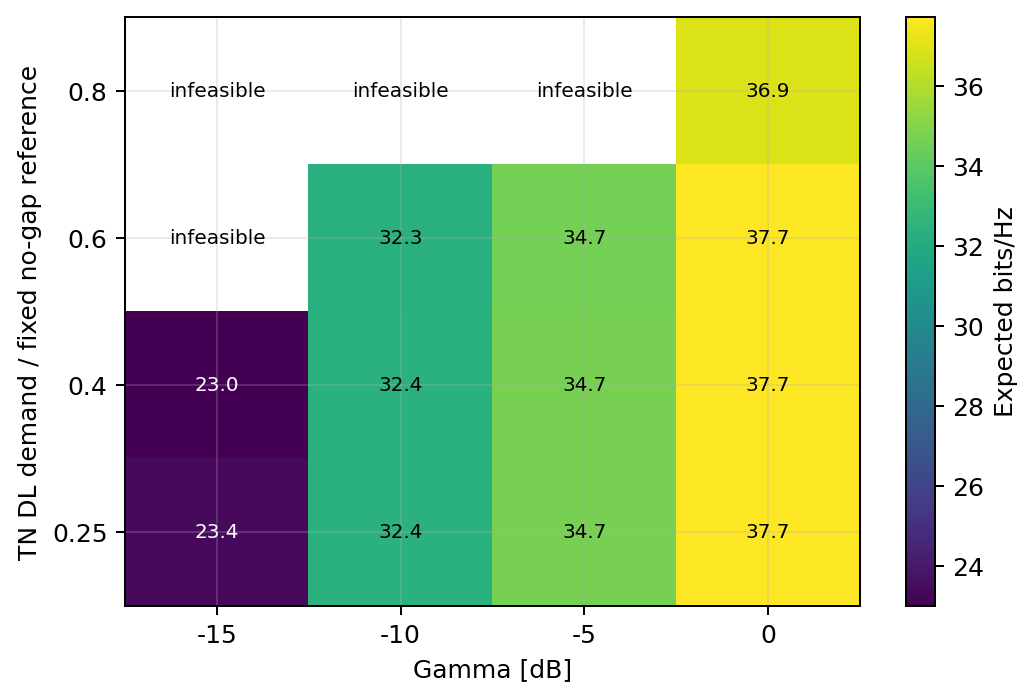

**All PDF / CSV / LaTeX / JSON files:** `/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E7`

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E7/
  policy_J_gamma_-15.json
  policy_F_gamma_-10.json
  timeline_J_gamma_-10.csv
  inr_tn_samples_J_gamma_-5.csv
  policy_L_gamma_-10.json
  policy_T_gamma_-15.json
  timeline_J_gamma_-5.csv
  policy_T_gamma_-5.json
  gamma_inr_cdf.pdf
  inr_tn_samples_J_gamma_0.csv
  timeline_J_gamma_0.csv
  socp_diagnostics_gamma_0.csv
  episode_metrics.csv
  policy_J_gamma_-5.json
  strategy_summary.csv
  policy_L_gamma_0.json
  policy_L_gamma_-5.json
  tn_demand_feasibility.pdf
  policy_L_gamma_-15.json
  policy_F_gamma_-15.json
  inr_tn_samples_J_gamma_-10.csv
  summary.json
  socp_diagnostics_gamma_-5.csv
  policy_J_gamma_0.json
  timeline.pdf
  tn_demand_sensitivity.csv
  policy_F_gamma_-5.json
  silent_ntn_and_tn_cdf.pdf
  policy_T_gamma_0.json
  socp_diagnostics_gamma_-15.csv
  service_protection_tradeoff.pdf
  timeline_J_gamma_-15.csv
  inr_tn_samples_J_gamma_-15.csv
  strategy_table.tex
  socp_diagnostics_gamma_-10.csv
  policy_F_gamma_0.json
  policy_T_gamma_-10.json
  policy_J_gamma_-10.json

In [8]:
show_results('E7')

## E8

Failures and delays, UL-silent background, gain and observation-kernel mismatch, unavailable listening gaps, and new arrivals.

Additional diagnostics explicitly exercise the mechanisms under test:

- A declared repeated-listening policy compares independent versus temporally correlated observation outcomes on paired physical trajectories. Listening counts and repeated-observation coverage are reported.
- Random hidden arrivals compare prior background protection, no response, and delayed observation-driven protection. UL-active and permanently UL-silent newcomers are evaluated separately, with detection/release times and pre/post-protection exposure.

These added diagnostics use declared causal policies; they do not claim global LP optimality for random arrivals. Without a prior envelope, an always-UL-silent newcomer cannot be discovered through passive UL listening. Mismatch experiments do not retain the original model-based guarantees.


**random_arrival/random_arrival_comparison.png**

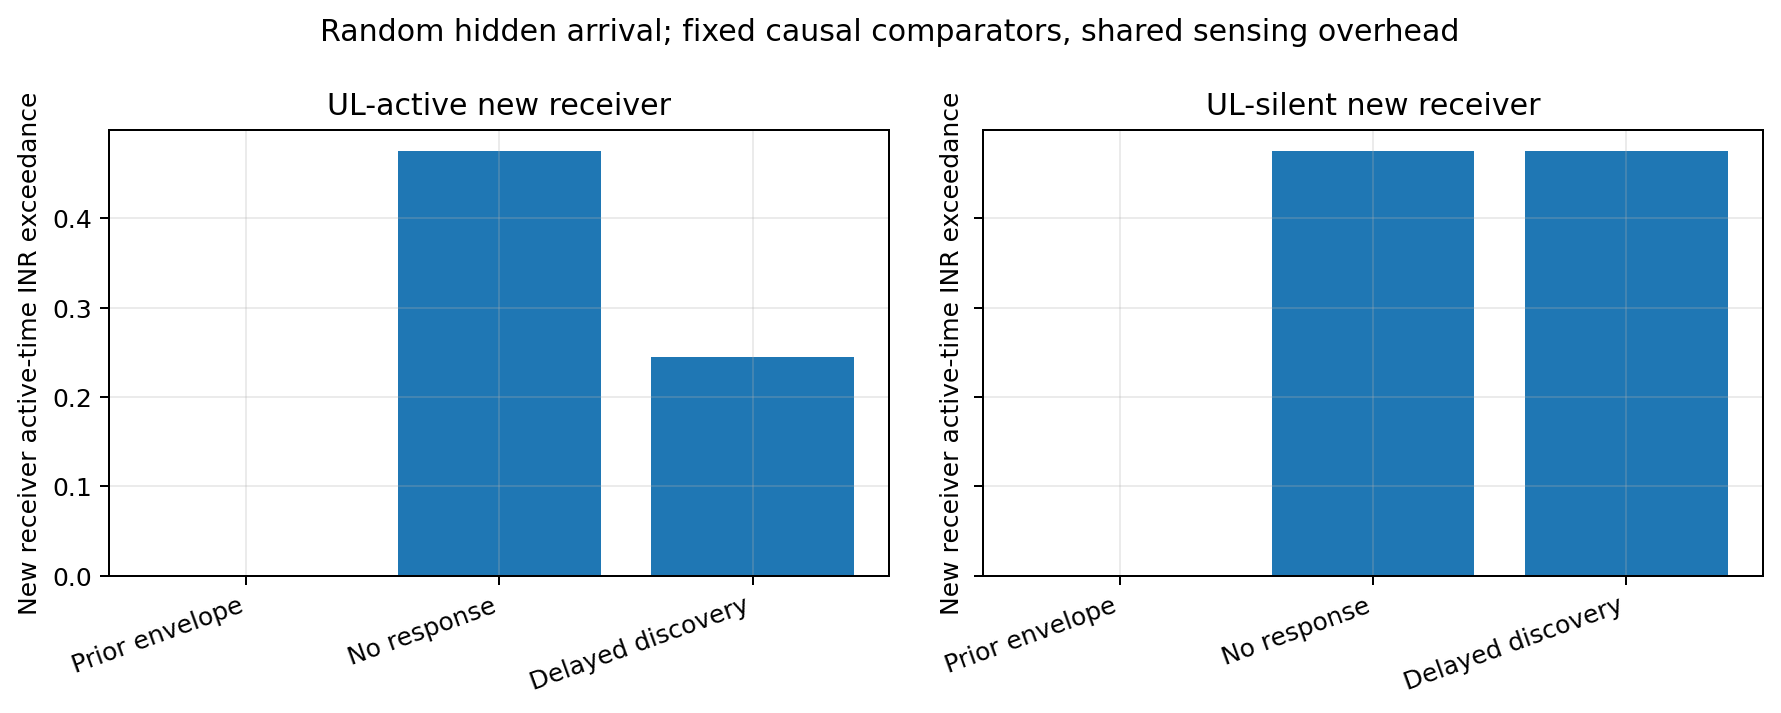

**repeated_observation/repeated_observation_comparison.png**

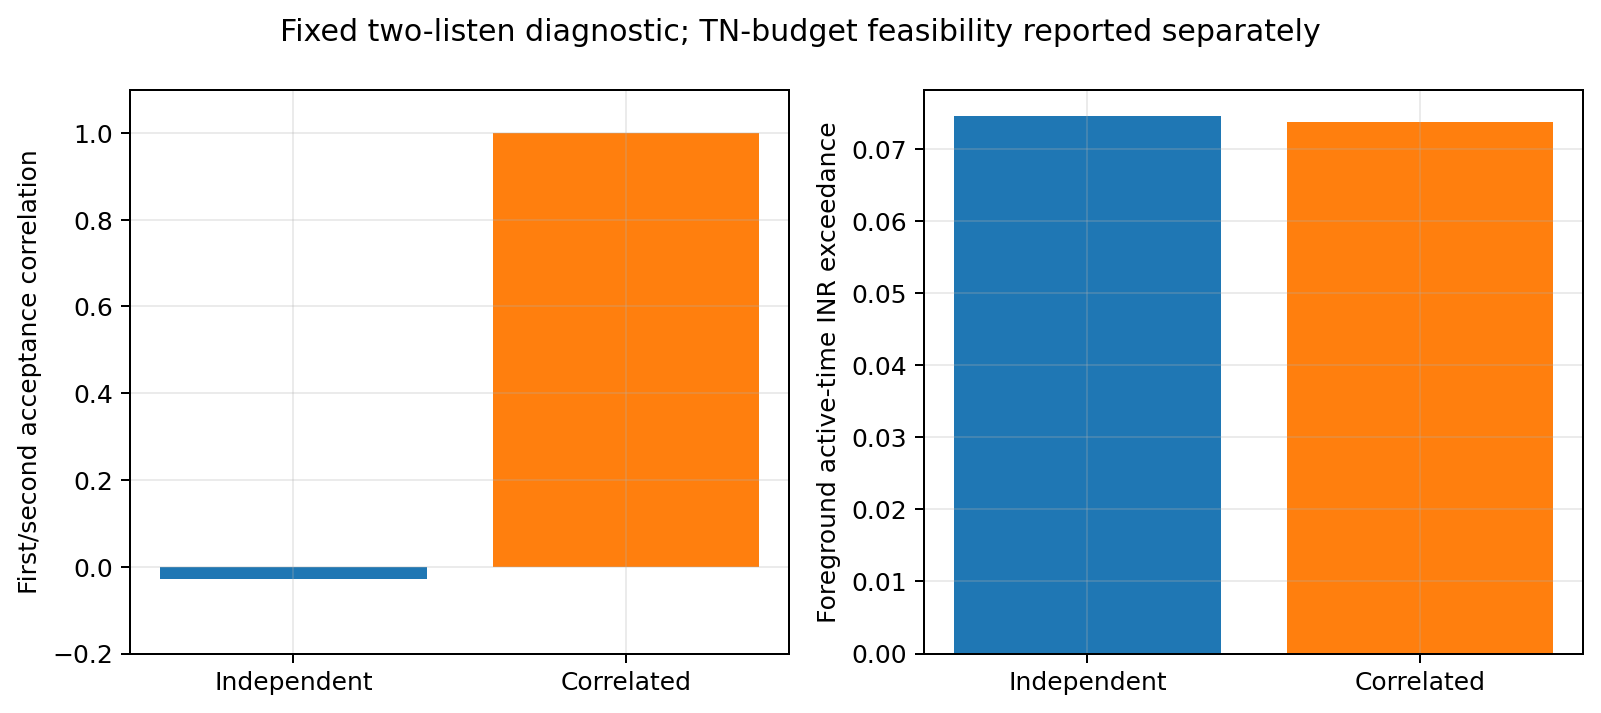

**stress_comparison.png**

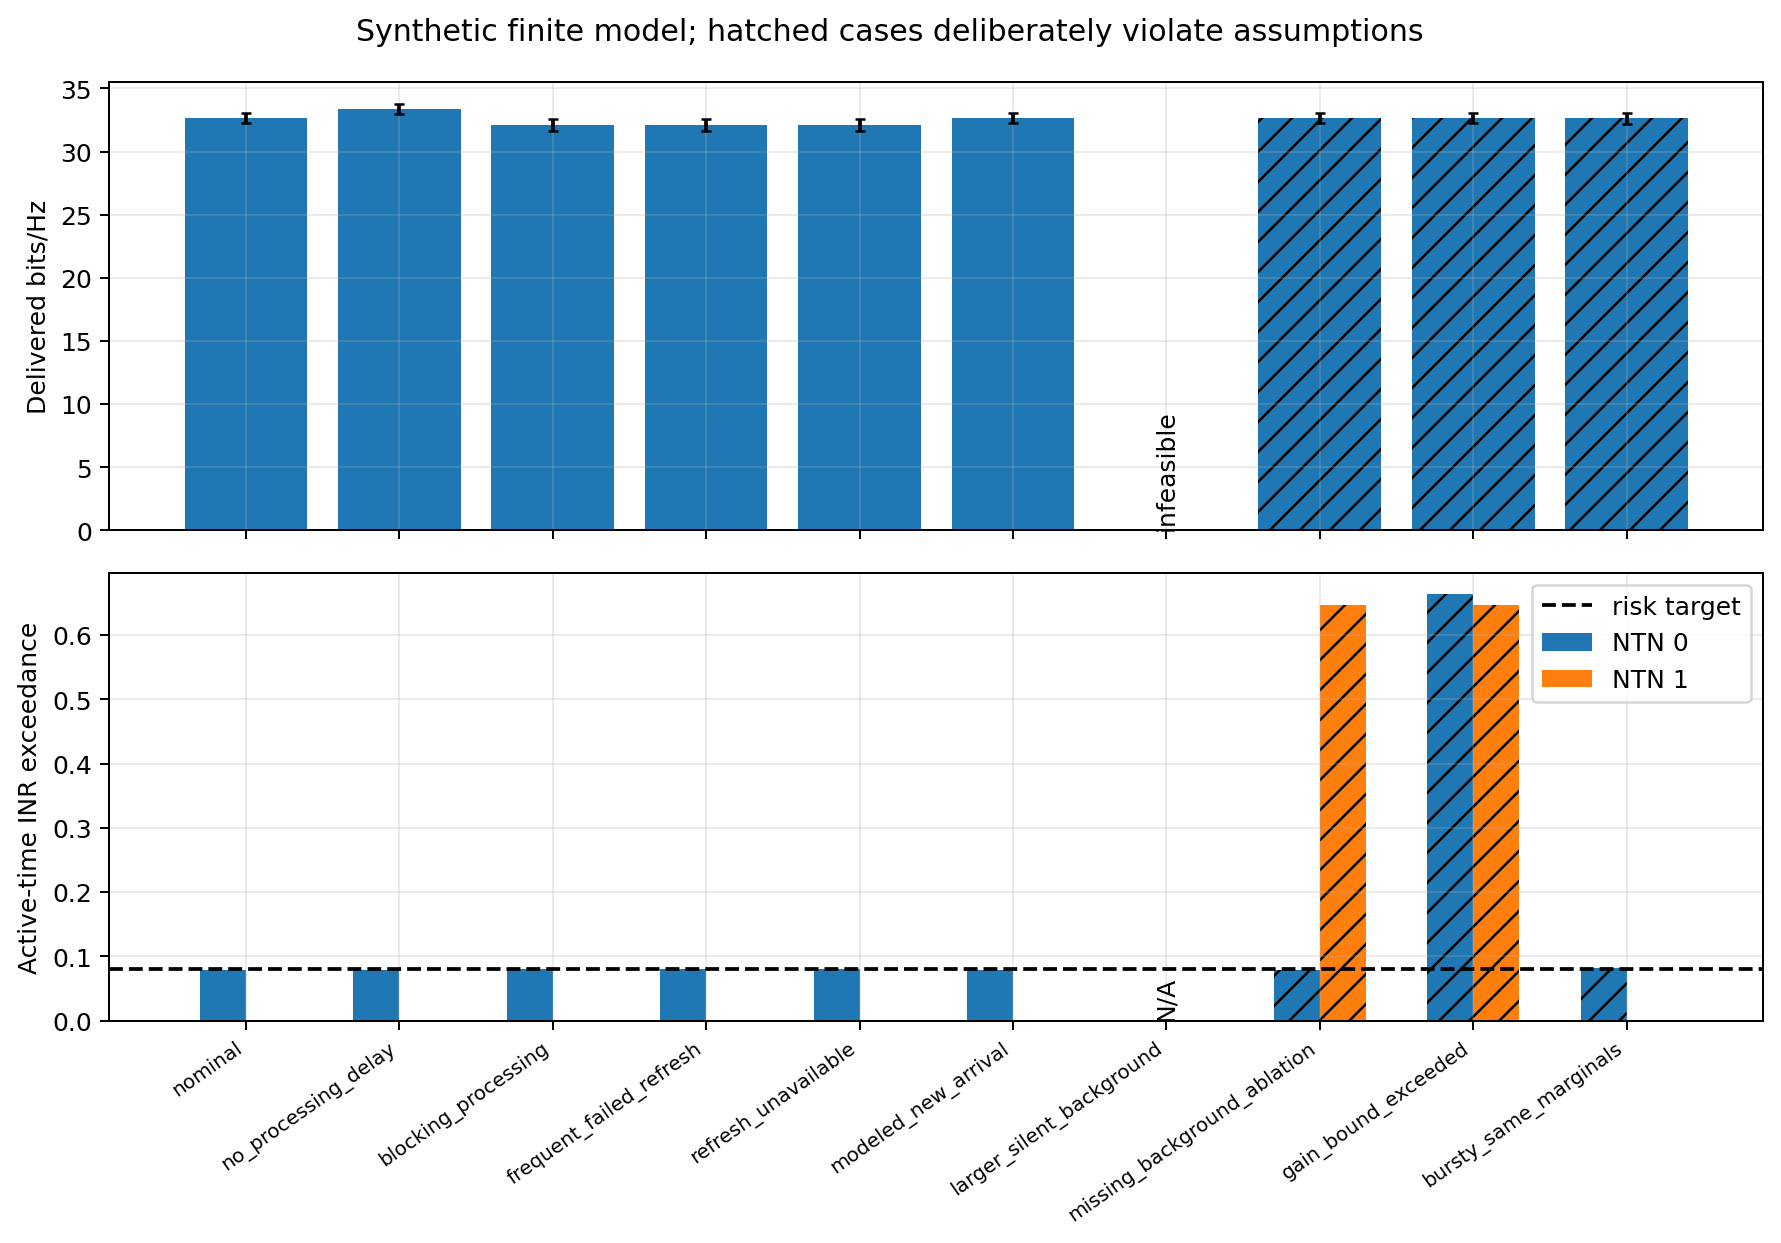

**All PDF / CSV / LaTeX / JSON files:** `/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E8`

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E8/
  refresh_unavailable_inr.csv
  frequent_failed_refresh_timeline.csv
  frequent_failed_refresh_episodes.csv
  missing_background_ablation_timeline.csv
  modeled_new_arrival_episodes.csv
  modeled_new_arrival_inr.csv
  nominal_timeline.csv
  blocking_processing_timeline.csv
  blocking_processing_inr.csv
  modeled_new_arrival_timeline.csv
  stress_table.tex
  stress_comparison.pdf
  no_processing_delay_inr.csv
  no_processing_delay_timeline.csv
  bursty_same_marginals_timeline.csv
  summary.json
  missing_background_ablation_inr.csv
  stress_summary.csv
  missing_background_ablation_episodes.csv
  bursty_same_marginals_episodes.csv
  gain_bound_exceeded_timeline.csv
  gain_bound_exceeded_episodes.csv
  nominal_episodes.csv
  blocking_processing_episodes.csv
  refresh_unavailable_episodes.csv
  refresh_unavailable_timeline.csv
  frequent_failed_refresh_inr.csv
  gain_bound_exceeded_inr.csv
  bursty_same_marginals_inr.csv
  no_processing_delay_episodes.csv
  nominal_inr.csv

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E8/random_arrival/
  episode_events.csv
  summary.json
  tick_traces.csv
  random_arrival_comparison.pdf
  summary.csv

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/E8/repeated_observation/
  repeated_observation_comparison.pdf
  independent_episodes.csv
  paired_episode_differences.csv
  summary.json
  independent_first_episode_timeline.csv
  temporally_correlated_first_episode_timeline.csv
  summary.csv
  temporally_correlated_episodes.csv

In [9]:
show_results('E8')

## Sionna RT Spatial Results

With `SPATIAL_SOURCE = 'fresh_rt'`, each macro freshly drops UEs, traces DL and FDD UL propagation, and runs finite-sample MUSIC. The generated source channels and seeds are archived in `fresh_rt_cache`; the Γ-sweep results are in `fresh_rt_spatial`.

With `'cache'`, the corresponding results appear in `cached_spatial`. Both modes split whole macro drops into training/calibration/test and preserve TN-infeasible sectors in the evaluation. These are static, single-controlled-sector results, not dynamic activity-time guarantees or aggregate network INR.


**cached_coverage_and_tn_feasibility.png**

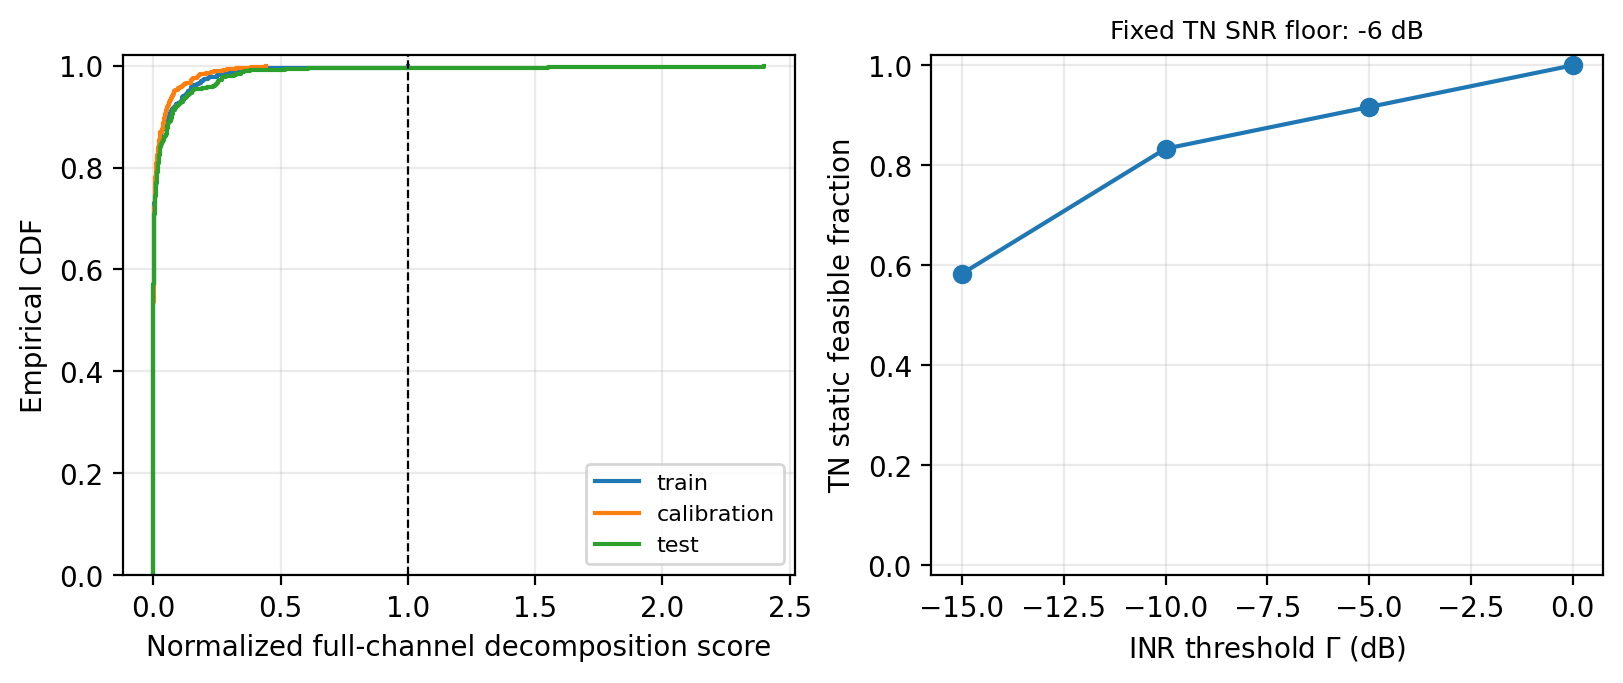

**cached_inr_cdf.png**

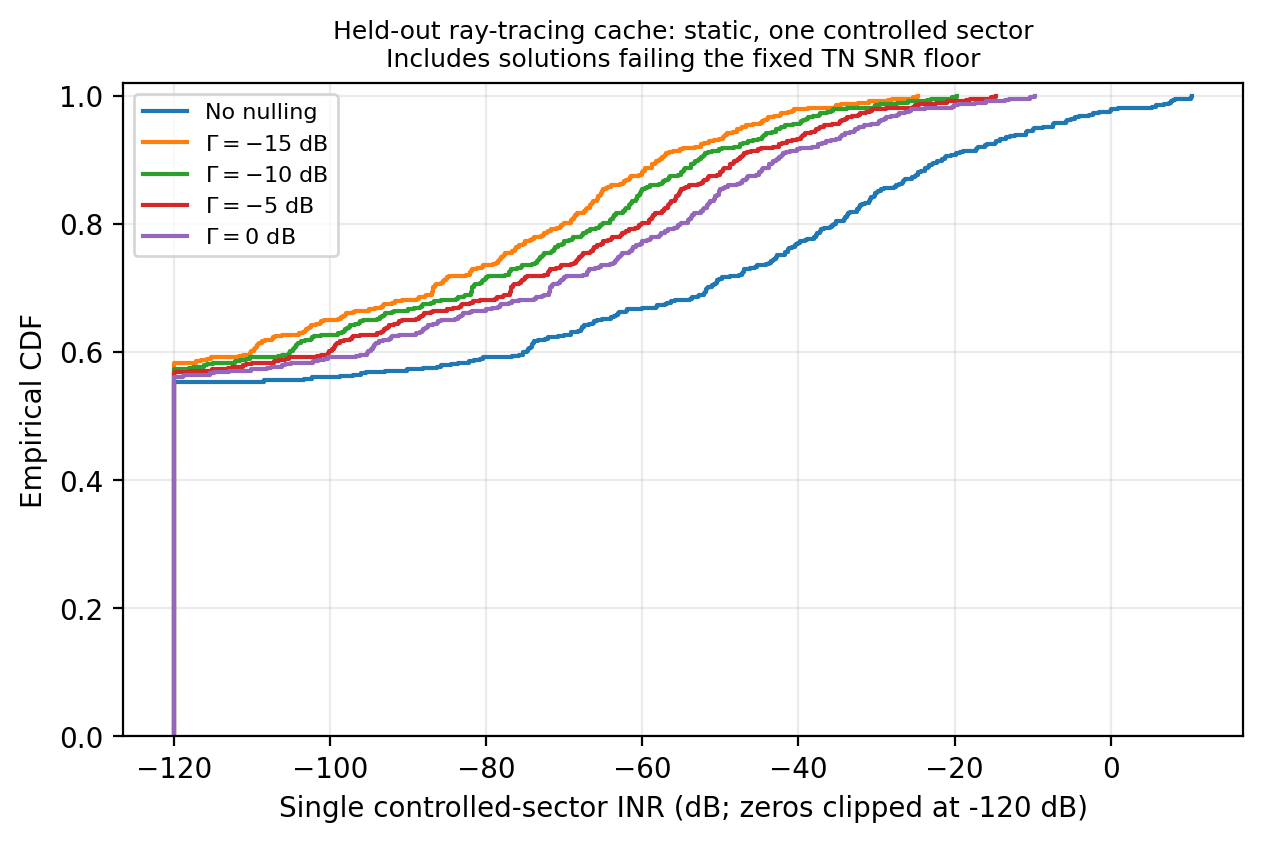

**cached_power_cdf.png**

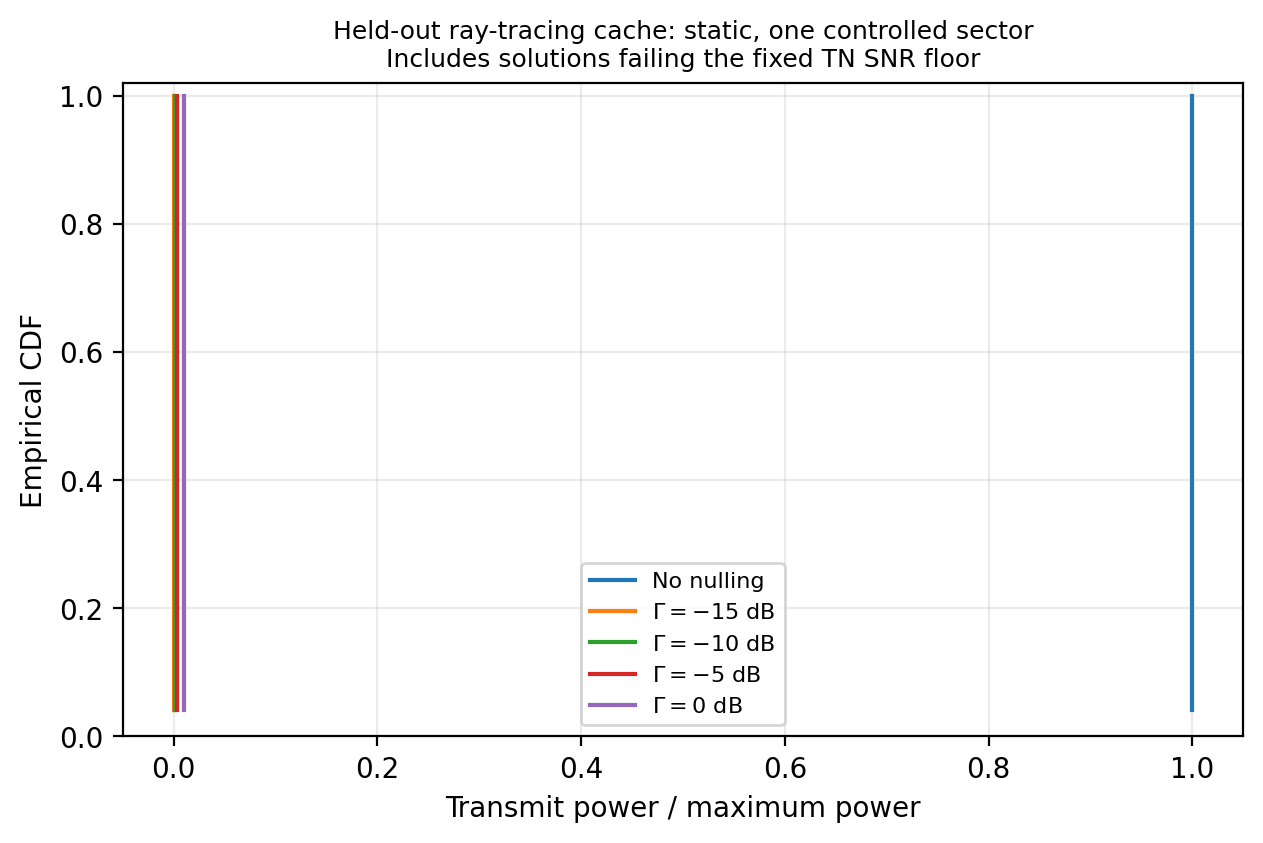

**cached_tn_snr_cdf.png**

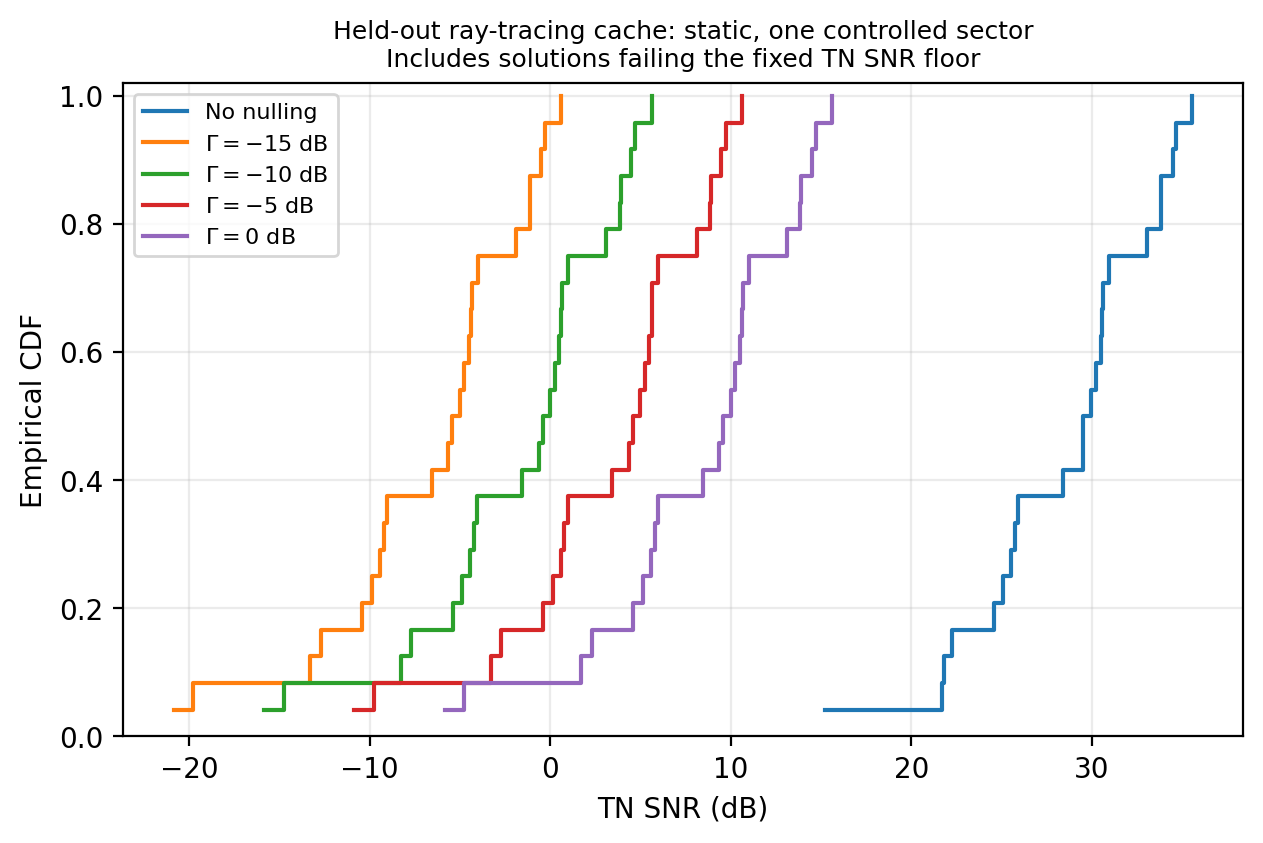

**All PDF / CSV / LaTeX / JSON files:** `/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/fresh_rt_spatial`

/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/appendix_d_20260921_235448_775259/fresh_rt_spatial/
  cached_power_cdf.pdf
  tn_samples.csv
  cached_inr_cdf.pdf
  cached_tn_snr_cdf.pdf
  summary.json
  gamma_summary.csv
  cached_coverage_and_tn_feasibility.pdf
  gamma_summary.tex
  calibration_coverage.csv
  ntn_samples.csv

In [10]:
if SPATIAL_SOURCE == 'fresh_rt':
    show_results('fresh_rt_spatial')
elif SPATIAL_SOURCE == 'cache':
    show_results('cached_spatial')
else:
    display(Markdown('Spatial RT validation was disabled for this run.'))
